In [1]:
import os
import pandas as pd
import numpy as np


In [13]:
import os
import pandas as pd
import numpy as np


BASE_DIR = "/Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Project"
OUTPUT_DIR = "/Users/haseebshafi/Documents/GitHub/Computational-Social-Science-2026/Final_project/Graph" 
YEARS = range(1988, 2008)  # 1988 to 2008 inclusive


def load_csv(filepath):
    df = pd.read_csv(filepath, low_memory=False, encoding="latin1")
    df = df.replace("NA", np.nan)
    return df


def clean_flight_data(df):
    df = df.copy()

    numeric_cols = [
        "AirTime",
        "ActualElapsedTime",
        "CRSElapsedTime",
        "ArrDelay",
        "DepDelay",
        "Distance",
        "Cancelled",
        "Diverted",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "Distance" in df.columns:
        df["Distance_km"] = df["Distance"] * 1.60934
        df = df.drop(columns=["Distance"])
        df = df.rename(columns={"Distance_km": "Distance"})

    return df


def compute_yearly_stats(df, year):
    total_flights = len(df)
    cancelled = df["Cancelled"].sum() if "Cancelled" in df.columns else np.nan
    diverted = df["Diverted"].sum() if "Diverted" in df.columns else np.nan

    stats = {
        "year": year,
        "total_flights": total_flights,
        "cancelled_flights": int(cancelled) if not np.isnan(cancelled) else np.nan,
        "diverted_flights": int(diverted) if not np.isnan(diverted) else np.nan,
        "cancellation_rate_pct": round(cancelled / total_flights * 100, 4) if total_flights > 0 else np.nan,
        "avg_dep_delay_min": round(df["DepDelay"].mean(), 2) if "DepDelay" in df.columns else np.nan,
        "avg_arr_delay_min": round(df["ArrDelay"].mean(), 2) if "ArrDelay" in df.columns else np.nan,
        "avg_air_time_min": round(df["AirTime"].mean(), 2) if "AirTime" in df.columns else np.nan,
        "avg_actual_elapsed_time_min": round(df["ActualElapsedTime"].mean(), 2) if "ActualElapsedTime" in df.columns else np.nan,
        "avg_scheduled_elapsed_time_min": round(df["CRSElapsedTime"].mean(), 2) if "CRSElapsedTime" in df.columns else np.nan,
        "avg_distance_km": round(df["Distance"].mean(), 2) if "Distance" in df.columns else np.nan,
        "unique_origins": df["Origin"].nunique() if "Origin" in df.columns else np.nan,
        "unique_destinations": df["Dest"].nunique() if "Dest" in df.columns else np.nan,
        "unique_carriers": df["UniqueCarrier"].nunique() if "UniqueCarrier" in df.columns else np.nan,
        "pct_flights_delayed_dep": round((df["DepDelay"] > 0).sum() / total_flights * 100, 2) if "DepDelay" in df.columns else np.nan,
        "pct_flights_delayed_arr": round((df["ArrDelay"] > 0).sum() / total_flights * 100, 2) if "ArrDelay" in df.columns else np.nan,
    }

    return stats


def main():
    all_stats = []

    for year in YEARS:
        filepath = os.path.join(BASE_DIR, f"{year}.csv")

        if not os.path.exists(filepath):
            print(f"  [SKIP] {year}.csv not found, skipping.")
            continue

        print(f"Processing {year}...")
        df = load_csv(filepath)
        df = clean_flight_data(df)

        stats = compute_yearly_stats(df, year)
        all_stats.append(stats)

        print(f"  -> {stats['total_flights']:,} flights | "
              f"avg dep delay: {stats['avg_dep_delay_min']} min | "
              f"avg air time: {stats['avg_air_time_min']} min")

    summary_df = pd.DataFrame(all_stats)
    output_path = os.path.join(OUTPUT_DIR, "yearly_flight_stats_1988_2007.csv")
    summary_df.to_csv(output_path, index=False)
    print(f"\nSaved yearly stats to: {output_path}")
    print(summary_df.to_string(index=False))


if __name__ == "__main__":
    main()

Processing 1988...
  -> 5,202,096 flights | avg dep delay: 6.71 min | avg air time: nan min
Processing 1989...
  -> 5,041,200 flights | avg dep delay: 8.2 min | avg air time: nan min
Processing 1990...
  -> 5,270,893 flights | avg dep delay: 6.91 min | avg air time: nan min
Processing 1991...
  -> 5,076,925 flights | avg dep delay: 5.75 min | avg air time: nan min
Processing 1992...
  -> 5,092,157 flights | avg dep delay: 5.69 min | avg air time: nan min
Processing 1993...
  -> 5,070,501 flights | avg dep delay: 6.12 min | avg air time: nan min
Processing 1994...
  -> 5,180,048 flights | avg dep delay: 6.66 min | avg air time: nan min
Processing 1995...
  -> 5,327,435 flights | avg dep delay: 8.28 min | avg air time: 97.28 min
Processing 1996...
  -> 5,351,983 flights | avg dep delay: 9.99 min | avg air time: 99.71 min
Processing 1997...
  -> 5,411,843 flights | avg dep delay: 8.24 min | avg air time: 101.28 min
Processing 1998...
  -> 5,384,721 flights | avg dep delay: 9.02 min | avg 

In [19]:
import os
print(os.getcwd())
print(os.listdir())

/Users/haseebshafi/Documents/GitHub/Computational-Social-Science-2026/Final_project/Graph
['edges_2002_2003.csv', 'pictures', 'edges_1999_2000.csv', 'data_analysis_yearly.ipynb', 'yearly_flight_stats_1988_2007.csv', 'airport_node_analysis_2008.csv', 'Graph_analysis_1999-2003.ipynb', 'airport_nodes_2002_2003.csv', 'yearly_flight_stats_plot.png', 'airport_nodes_1999_2000.csv', 'yearly_flight_stats_combined.png']


Saved to: yearly_flight_stats_combined.png


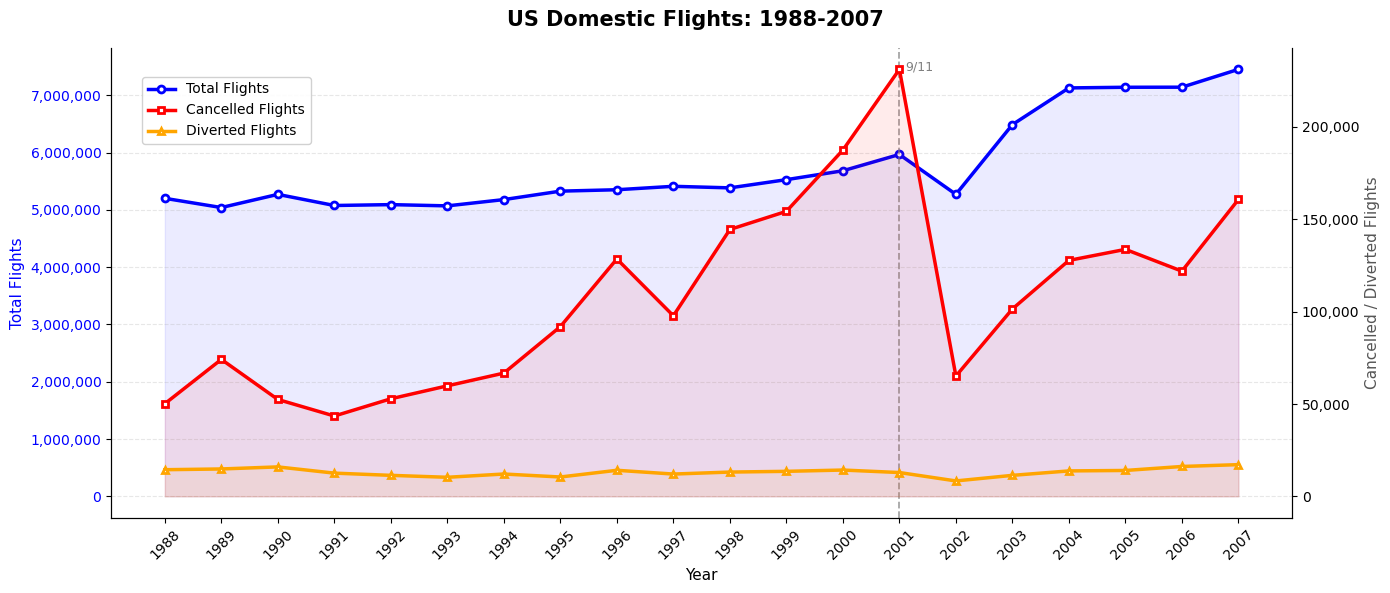

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

CSV_PATH = "yearly_flight_stats_1988_2007.csv"

df = pd.read_csv(CSV_PATH)
df = df.sort_values("year")

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# --- Left axis: total flights ---
l1, = ax1.plot(df["year"], df["total_flights"], color="blue", linewidth=2.5,
               marker="o", markersize=5, markerfacecolor="white", markeredgewidth=2,
               label="Total Flights")
ax1.fill_between(df["year"], df["total_flights"], alpha=0.08, color="blue")

# --- Right axis: cancelled & diverted ---
l2, = ax2.plot(df["year"], df["cancelled_flights"], color="red", linewidth=2.5,
               marker="s", markersize=5, markerfacecolor="white", markeredgewidth=2,
               label="Cancelled Flights")
ax2.fill_between(df["year"], df["cancelled_flights"], alpha=0.08, color="red")

l3, = ax2.plot(df["year"], df["diverted_flights"], color="orange", linewidth=2.5,
               marker="^", markersize=5, markerfacecolor="white", markeredgewidth=2,
               label="Diverted Flights")
ax2.fill_between(df["year"], df["diverted_flights"], alpha=0.08, color="orange")


ax1.axvline(x=2001, color="gray", linestyle="--", linewidth=1.3, alpha=0.7)
ax1.text(2001.1, ax1.get_ylim()[1] * 0.95, "9/11", color="gray", fontsize=9)

ax1.set_xlabel("Year", fontsize=11)
ax1.set_ylabel("Total Flights", fontsize=11, color="blue")
ax2.set_ylabel("Cancelled / Diverted Flights", fontsize=11, color="#555")

ax1.tick_params(axis="y", labelcolor="blue")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax1.set_xticks(df["year"])
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)

fig.suptitle("US Domestic Flights: 1988-2007", fontsize=15, fontweight="bold")
fig.legend(handles=[l1, l2, l3], loc="upper left",
           bbox_to_anchor=(0.1, 0.88), framealpha=0.9, fontsize=10)

plt.tight_layout()
output_path = os.path.join(os.path.dirname(CSV_PATH), "yearly_flight_stats_combined.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Saved to: {output_path}")
plt.show()

#### yealy mapped graphs

In [ ]:
import os
import pandas as pd
import numpy as np

BASE_DIR = "/Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Project"
AIRPORTS_CSV = "/Users/haseebshafi/Documents/GitHub/Computational-Social-Science-2026/Final_project/Graph/airports.csv"

# Load once at module level — reused by all function calls
AIRPORT_COORDS = (
    pd.read_csv(AIRPORTS_CSV, encoding="latin1")
    [["iata", "lat", "long"]]
    .rename(columns={"iata": "IATA", "long": "lon"})
    .drop_duplicates(subset="IATA")
)


def load_and_combine_csvs(files, period_name=None):
    dfs = []
    for file in files:
        df = pd.read_csv(file, low_memory=False, encoding="latin1")
        year = os.path.basename(file)[:4]
        df["year"] = pd.to_numeric(year, errors="coerce")
        if period_name is not None:
            df["period"] = period_name
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


def clean_flight_data(df):
    df = df.copy()
    df = df.replace("NA", np.nan)

    numeric_cols = [
        "AirTime", "ActualElapsedTime", "CRSElapsedTime",
        "ArrDelay", "DepDelay", "Distance", "Cancelled", "Diverted",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "Distance" in df.columns:
        df["Distance_km"] = df["Distance"] * 1.60934
        df = df.drop(columns=["Distance"]).rename(columns={"Distance_km": "Distance"})

    return df


def build_airport_nodes(df):
    required_cols = ["Origin", "Dest"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    origin_stats = (
        df.groupby("Origin")
        .agg(
            origin_flight_count=("Origin", "size"),
            avg_actual_elapsed_time=("ActualElapsedTime", "mean"),
            avg_scheduled_elapsed_time=("CRSElapsedTime", "mean"),
            avg_air_time=("AirTime", "mean"),
            avg_distance=("Distance", "mean"),
            avg_dep_delay=("DepDelay", "mean"),
            cancelled_origin_count=("Cancelled", "sum"),
            diverted_origin_count=("Diverted", "sum"),
            unique_destinations=("Dest", "nunique"),
        )
        .reset_index()
        .rename(columns={"Origin": "IATA"})
    )

    dest_stats = (
        df.groupby("Dest")
        .agg(
            dest_flight_count=("Dest", "size"),
            avg_arr_delay=("ArrDelay", "mean"),
            unique_origins=("Origin", "nunique"),
        )
        .reset_index()
        .rename(columns={"Dest": "IATA"})
    )

    airport_nodes = pd.merge(origin_stats, dest_stats, on="IATA", how="outer")

    count_cols = [
        "origin_flight_count", "dest_flight_count",
        "cancelled_origin_count", "diverted_origin_count",
        "unique_destinations", "unique_origins",
    ]
    for col in count_cols:
        airport_nodes[col] = airport_nodes[col].fillna(0)

    airport_nodes["flight_count"] = (
        airport_nodes["origin_flight_count"] + airport_nodes["dest_flight_count"]
    )
    airport_nodes["unique_connections"] = (
        airport_nodes["unique_destinations"] + airport_nodes["unique_origins"]
    )
    airport_nodes["avg_flight_time"] = airport_nodes["avg_actual_elapsed_time"]

    round_cols = [
        "avg_flight_time", "avg_actual_elapsed_time", "avg_scheduled_elapsed_time",
        "avg_air_time", "avg_distance", "avg_dep_delay", "avg_arr_delay",
    ]
    for col in round_cols:
        airport_nodes[col] = airport_nodes[col].round(2)

    # --- Attach lat/lon from the globally loaded AIRPORT_COORDS ---
    airport_nodes = pd.merge(airport_nodes, AIRPORT_COORDS, on="IATA", how="left")

    unmatched = airport_nodes[airport_nodes["lat"].isna()]["IATA"].tolist()
    if unmatched:
        print(f"  [WARN] No coordinates found for {len(unmatched)} airports: {unmatched[:10]}{'...' if len(unmatched) > 10 else ''}")

    airport_nodes = airport_nodes[
        [
            "IATA", "lat", "lon",
            "flight_count", "origin_flight_count", "dest_flight_count",
            "avg_flight_time", "avg_actual_elapsed_time", "avg_scheduled_elapsed_time",
            "avg_air_time", "avg_distance", "avg_dep_delay", "avg_arr_delay",
            "cancelled_origin_count", "diverted_origin_count",
            "unique_destinations", "unique_origins", "unique_connections",
        ]
    ].sort_values("flight_count", ascending=False)

    return airport_nodes


def save_airport_nodes(files, period_name, output_dir=BASE_DIR):
    """
    Build and save airport node stats for a given period.

    Parameters
    ----------
    files : list of str
        CSV file paths for the period (one per year).
    period_name : str
        Label used in the output filename, e.g. "1999-2000".
    output_dir : str
        Where to save the output CSV.

    Returns
    -------
    pd.DataFrame
    """
    print(f"Processing period: {period_name} ({len(files)} file(s))...")
    df = load_and_combine_csvs(files, period_name=period_name)
    df = clean_flight_data(df)
    airport_nodes = build_airport_nodes(df)

    safe_name = period_name.replace(" ", "_").replace("-", "_")
    output_path = os.path.join(output_dir, f"airport_nodes_{safe_name}.csv")
    airport_nodes.to_csv(output_path, index=False)
    print(f"  Saved: {output_path} ({len(airport_nodes)} airports)")

    return airport_nodes


# # --- Usage ---
# nodes_1999_2000 = save_airport_nodes(
#     files=[
#         os.path.join(BASE_DIR, "1999.csv"),
#         os.path.join(BASE_DIR, "2000.csv"),
#     ],
#     period_name="1999-2000",
# )

# nodes_2002_2003 = save_airport_nodes(
#     files=[
#         os.path.join(BASE_DIR, "2002.csv"),
#         os.path.join(BASE_DIR, "2003.csv"),
#     ],
#     period_name="2002-2003",
# )

# In your preprocessing script, add this function alongside save_airport_nodes:

def save_edges_for_period(files, period_name, output_dir=BASE_DIR):
    """
    Build and save edge list for a given period.
    """
    print(f"Building edges for period: {period_name} ({len(files)} file(s))...")
    df = load_and_combine_csvs(files, period_name=period_name)
    df = clean_flight_data(df)

    edges = (
        df.groupby(["Origin", "Dest"])
        .agg(
            flight_count  = ("Origin", "size"),
            avg_distance  = ("Distance", "mean"),
            avg_air_time  = ("AirTime", "mean"),
            avg_dep_delay = ("DepDelay", "mean"),
            avg_arr_delay = ("ArrDelay", "mean"),
        )
        .reset_index()
    )

    round_cols = ["avg_distance", "avg_air_time", "avg_dep_delay", "avg_arr_delay"]
    edges[round_cols] = edges[round_cols].round(2)

    safe_name   = period_name.replace(" ", "_").replace("-", "_")
    output_path = os.path.join(output_dir, f"edges_{safe_name}.csv")
    edges.to_csv(output_path, index=False)
    print(f"  Saved: {output_path} ({len(edges)} edges)")

    return edges


# --- Usage: nodes + edges for each period ---

periods = [
    ("1988-1992", range(1988, 1993)),
    ("1993-1997", range(1993, 1998)),
    ("1998-2002", range(1998, 2003)),
    ("2003-2007", range(2003, 2008)),
]

# for period_name, years in periods:
#     files = [os.path.join(BASE_DIR, f"{y}.csv") for y in years]
#     save_airport_nodes(files, period_name)
#     save_edges_for_period(files, period_name)

Processing period: 1988-1992 (5 file(s))...
  Saved: /Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Project/airport_nodes_1988_1992.csv (260 airports)
Building edges for period: 1988-1992 (5 file(s))...
  Saved: /Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Project/edges_1988_1992.csv (4723 edges)
Processing period: 1993-1997 (5 file(s))...
  Saved: /Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Project/airport_nodes_1993_1997.csv (234 airports)
Building edges for period: 1993-1997 (5 file(s))...
  Saved: /Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/Project/edges_1993_1997.csv (4075 edges)
Processing period: 1998-2002 (5 file(s))...
  Saved: /Users/haseebshafi/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/4. Semester/02467 - ComSocSci/

In [40]:
import pandas as pd
import numpy as np
import networkx as nx
from netwulf import visualize
import community as community_louvain
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from collections import Counter

years = "1988_1992"

# 1. Load edge data
df_edges = pd.read_csv(f"../Graph/data_5year_split/edges_{years}.csv")

G = nx.Graph()
for _, row in df_edges.iterrows():
    origin = row["Origin"]
    dest   = row["Dest"]
    weight = row["flight_count"]
    if G.has_edge(origin, dest):
        G[origin][dest]["weight"] += weight
    else:
        G.add_edge(origin, dest,
                   weight        = weight,
                   avg_distance  = row.get("avg_distance"),
                   avg_air_time  = row.get("avg_air_time"),
                   avg_dep_delay = row.get("avg_dep_delay"),
                   avg_arr_delay = row.get("avg_arr_delay"))

# 2. Load node metadata
df_nodes = pd.read_csv(f"../Graph/data_5year_split/airport_nodes_{years}.csv")
df_nodes = df_nodes[df_nodes["IATA"].isin(G.nodes())].copy()
df_nodes = df_nodes.replace([np.inf, -np.inf], np.nan)
df_nodes = df_nodes.astype(object).where(pd.notnull(df_nodes), None)
nx.set_node_attributes(G, df_nodes.set_index("IATA").to_dict(orient="index"))

# 3. Strength + top 10
strength_dict = dict(G.degree(weight="weight"))
nx.set_node_attributes(G, strength_dict, "strength")
top10     = sorted(strength_dict, key=strength_dict.get, reverse=True)[:10]
top10_set = set(top10)

# 4. Louvain community detection
partition   = community_louvain.best_partition(G, weight="weight", random_state=42)
nx.set_node_attributes(G, partition, "community")

comm_sizes     = Counter(partition.values())
top5_comms     = [c for c, _ in comm_sizes.most_common(5)]
cmap           = cm.get_cmap("tab10")
comm_color_map = {}
comm_label_map = {}

for i, comm in enumerate(top5_comms):
    comm_color_map[comm] = mcolors.to_hex(cmap(i))
    comm_label_map[comm] = f"Community {i + 1} (n={comm_sizes[comm]})"

for comm in partition.values():
    if comm not in comm_color_map:
        comm_color_map[comm] = "#cccccc"

# 5. Apply community colors, labels, sizes  ← single authoritative block
for n in G.nodes:
    comm  = partition.get(n, -1)
    color = comm_color_map.get(comm, "#cccccc")
    group = f"Community {top5_comms.index(comm) + 1}" if comm in top5_comms else "Other"

    G.nodes[n]["color"] = color
    G.nodes[n]["group"] = group
    G.nodes[n]["label"] = n if n in top10_set else ""
    G.nodes[n]["size"]  = max(2, np.log1p(G.nodes[n].get("strength", 0)) * 3)

# 6. Clean node / edge attrs
for n, attrs in G.nodes(data=True):
    for k, v in list(attrs.items()):
        try:
            if pd.isna(v):
                G.nodes[n][k] = None
        except (TypeError, ValueError):
            pass

for u, v, attrs in G.edges(data=True):
    for k, val in list(attrs.items()):
        try:
            if pd.isna(val):
                G.edges[u, v][k] = 0
        except (TypeError, ValueError):
            pass

# 7. Convert for netwulf
graph_data = nx.json_graph.node_link_data(G)
if "edges" in graph_data:
    graph_data["links"] = graph_data.pop("edges")

# 8. Top-10 table
top10_table = pd.DataFrame({
    "IATA":                   top10,
    "community":              [G.nodes[n].get("group") for n in top10],
    "strength":               [G.nodes[n].get("strength") for n in top10],
    "avg_airtime":            [G.nodes[n].get("avg_air_time") for n in top10],
    "avg_distance":           [G.nodes[n].get("avg_distance") for n in top10],
    "avg_dep_delay":          [G.nodes[n].get("avg_dep_delay") for n in top10],
    "avg_arr_delay":          [G.nodes[n].get("avg_arr_delay") for n in top10],
    "cancelled_origin_count": [G.nodes[n].get("cancelled_origin_count") for n in top10],
    "diverted_origin_count":  [G.nodes[n].get("diverted_origin_count") for n in top10],
})
print(top10_table.to_string(index=False))

# 9. Community legend
community_legend_elements = [
    Line2D([0], [0], marker="o", color="w",
           label=comm_label_map[comm],
           markerfacecolor=comm_color_map[comm],
           markersize=9)
    for comm in top5_comms
] + [
    Line2D([0], [0], marker="o", color="w",
           label=f"Other ({sum(v for k, v in comm_sizes.items() if k not in top5_comms)} airports)",
           markerfacecolor="#cccccc", markersize=9)
]
print("\nCommunity color legend:")
for comm in top5_comms:
    print(f"  {comm_label_map[comm]}: {comm_color_map[comm]}")

# 10. Visualize
config = {
    "preset": "Default",
    "closed": False,
    "remembered": {
        "Default": {
            "0": {
                "zoom": 1,
                "node_charge": -7.2,
                "node_gravity": 0.46,
                "link_distance": 14.4,
                "link_distance_variation": 0,
                "node_collision": True,
                "wiggle_nodes": False,
                "freeze_nodes": False,
                "node_fill_color": "#79aaa0",
                "node_stroke_color": "#555555",
                "node_label_color": "#000000",
                "node_size": 17,
                "node_stroke_width": 1,
                "node_size_variation": 0.5,
                "display_node_labels": True,
                "scale_node_size_by_strength": True,
                "link_color": "#7c7c7c",
                "link_width": 2,
                "link_alpha": 0.4,
                "link_width_variation": 0.5,
                "display_singleton_nodes": False,
                "min_link_weight_percentile": 0,
                "max_link_weight_percentile": 1,
            }
        }
    },
    "folders": {
        "Input/output":  {"preset": "Default", "closed": False, "folders": {}},
        "Physics":       {"preset": "Default", "closed": False, "folders": {}},
        "Nodes":         {"preset": "Default", "closed": False, "folders": {}},
        "Links":         {"preset": "Default", "closed": False, "folders": {}},
        "Thresholding":  {"preset": "Default", "closed": False, "folders": {}},
    },
}

stylized_network, config = visualize(graph_data, config=config)

/var/folders/qb/2g2dn0_s7w9dxjgx4qyk86dh0000gn/T/ipykernel_91714/1365315926.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap           = cm.get_cmap("tab10")


IATA   community  strength avg_airtime  avg_distance  avg_dep_delay  avg_arr_delay  cancelled_origin_count  diverted_origin_count
 ORD Community 1   2707312        None       1258.35           9.44           7.56                 21870.0                 3858.0
 DFW Community 3   2383639        None       1268.44           7.76           6.04                  8954.0                 2592.0
 ATL Community 1   2291667        None        905.50           7.96           7.00                 13141.0                 2241.0
 LAX Community 2   1629642        None       1629.67           6.89           6.70                  7503.0                 1711.0
 DEN Community 2   1452671        None       1347.86           8.21           7.36                  6222.0                 2764.0
 PHX Community 2   1332096        None       1075.58           6.88           5.22                  3271.0                 1283.0
 SFO Community 2   1263840        None       1567.25           7.91           8.90        

Nodes with coordinates: 260 / 260
Valid edge segments: 2491 / 2491


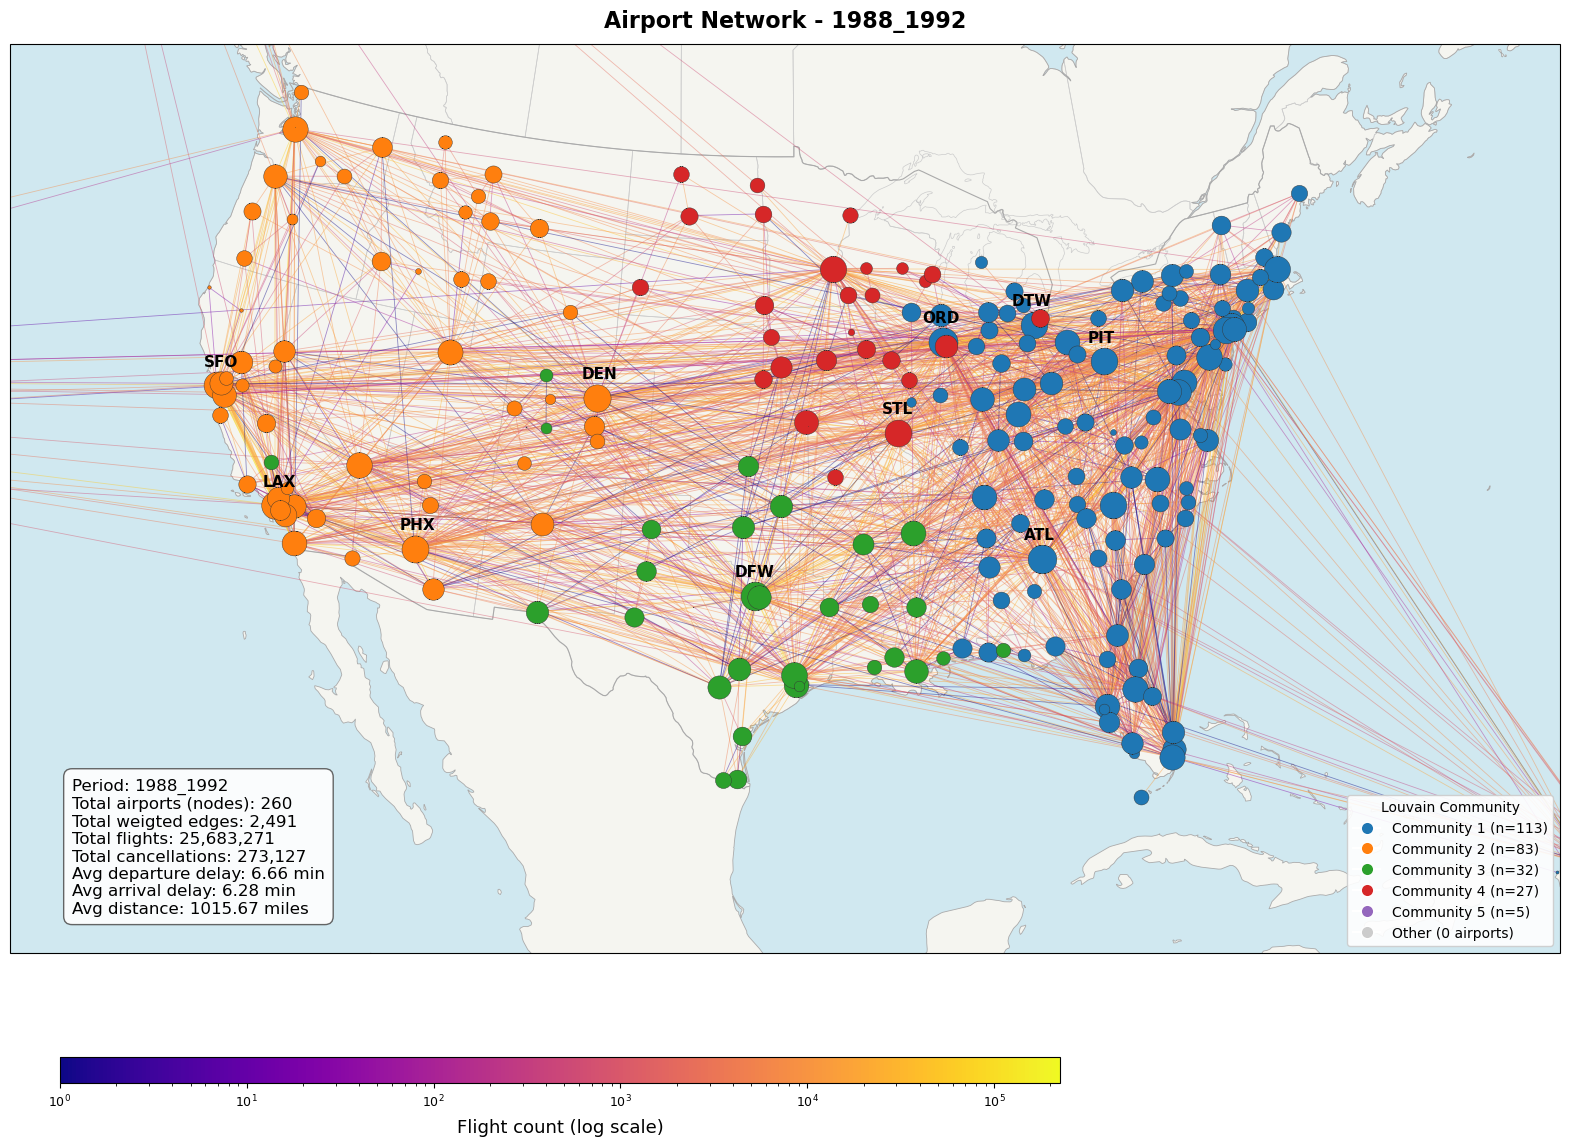

In [41]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#years = "1988_1992"

# --- Inject lat/lon from airport_nodes CSV into stylized_network ---
airport_nodes_df = pd.read_csv(f"../Graph/data_5year_split/airport_nodes_{years}.csv")
coords = airport_nodes_df.set_index("IATA")[["lat", "lon"]].to_dict(orient="index")

for node in stylized_network["nodes"]:
    nid = node["id"]
    if nid in coords:
        node["lat"] = coords[nid]["lat"]
        node["lon"] = coords[nid]["lon"]
    else:
        node["lat"] = None
        node["lon"] = None

# --- Setup ---
PROJ     = ccrs.LambertConformal(central_longitude=-96, central_latitude=39)
DATA_CRS = ccrs.PlateCarree()

fig = plt.figure(figsize=(20, 13))
ax  = fig.add_subplot(1, 1, 1, projection=PROJ)
ax.set_extent([-125, -66.5, 20, 50], crs=DATA_CRS)

# --- Base map ---
ax.add_feature(cfeature.LAND,      facecolor="#f5f5f0", zorder=0)
ax.add_feature(cfeature.OCEAN,     facecolor="#d0e8f0", zorder=0)
ax.add_feature(cfeature.STATES,    edgecolor="#cccccc", linewidth=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS,   edgecolor="#aaaaaa", linewidth=0.8, zorder=1)
ax.add_feature(cfeature.COASTLINE, edgecolor="#aaaaaa", linewidth=0.6, zorder=1)

nodes = stylized_network["nodes"]
links = stylized_network["links"]

# --- Position lookup (lon, lat) ---
pos = {
    node["id"]: (node["lon"], node["lat"])
    for node in nodes
    if node.get("lon") is not None and node.get("lat") is not None
}

print(f"Nodes with coordinates: {len(pos)} / {len(nodes)}")

def resolve_id(ref):
    return ref if isinstance(ref, str) else nodes[ref]["id"]

# --- Build projected edge segments ---
segments     = []
edge_weights = []

for link in links:
    src = resolve_id(link["source"])
    tgt = resolve_id(link["target"])
    if src in pos and tgt in pos:
        x0, y0 = ax.projection.transform_point(*pos[src], DATA_CRS)
        x1, y1 = ax.projection.transform_point(*pos[tgt], DATA_CRS)
        if not any(np.isnan([x0, y0, x1, y1])):
            segments.append([(x0, y0), (x1, y1)])
            edge_weights.append(link.get("weight", 1))

print(f"Valid edge segments: {len(segments)} / {len(links)}")

# --- Draw edges ---
if len(segments) > 0:
    edge_weights = np.array(edge_weights, dtype=float)
    norm = mcolors.LogNorm(vmin=edge_weights.min(), vmax=edge_weights.max())
    cmap = cm.plasma

    lc = LineCollection(
        segments,
        cmap=cmap, norm=norm,
        linewidths=0.6, alpha=0.45, zorder=2,
        transform=ax.transData,
    )
    lc.set_array(edge_weights)
    ax.add_collection(lc)
else:
    print("[WARN] No edges drawn — check lat/lon values")
    cmap = cm.plasma
    norm = mcolors.LogNorm(vmin=1, vmax=10) 

# --- Draw nodes ---
def strength_to_size(s, scale=0.005, power=3):
    log_s = max(2.0, np.log1p(float(s)) * 3.0)
    return (log_s ** power) * scale

for node in nodes:
    nid = node["id"]
    if nid not in pos:
        continue
    lon, lat  = pos[nid]
    color     = node.get("color", "#999999")
    strength  = G.nodes[nid].get("strength", 1) if nid in G.nodes else 1

    ax.scatter(
        lon, lat,
        color=color, s=strength_to_size(strength),
        zorder=4, edgecolors="#333333", linewidths=0.3,
        transform=DATA_CRS,
    )

# --- Label top-10 hubs ---
for node in nodes:
    if node["id"] in top10_set and node["id"] in pos:
        lon, lat = pos[node["id"]]
        ax.text(
            lon, lat + 0.6,
            node["id"],
            fontsize=11, fontweight="bold",
            ha="center", va="bottom", color="#000000",
            zorder=5, transform=DATA_CRS,
        )

# --- Colorbar ---
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.15, 0.04, 0.50, 0.020])
cbar    = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Flight count (log scale)", fontsize=13, labelpad=6)
cbar.ax.tick_params(labelsize=9)

ax.legend(
    handles=community_legend_elements,
    title="Louvain Community", loc="lower right",
    bbox_to_anchor=(1.0, 0.0),
    frameon=True, framealpha=0.9,
    fontsize=10, title_fontsize=10,
)

# --- Summary stats box ---
node_df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient="index")

# Convert columns safely to numeric
for col in [
    "strength",
    "avg_dep_delay",
    "avg_arr_delay",
    "avg_distance",
    "cancelled_origin_count",
]:
    if col in node_df.columns:
        node_df[col] = pd.to_numeric(node_df[col], errors="coerce")

# Use only rows with valid positive strength
valid = node_df["strength"].notna() & (node_df["strength"] > 0)

total_airports = len(node_df)

total_edges = len(links)

total_flights = sum(link.get("weight", 0) for link in links)

total_cancellations = node_df["cancelled_origin_count"].fillna(0).sum()

avg_dep_delay = np.average(
    node_df.loc[valid, "avg_dep_delay"].fillna(0),
    weights=node_df.loc[valid, "strength"]
)

avg_arr_delay = np.average(
    node_df.loc[valid, "avg_arr_delay"].fillna(0),
    weights=node_df.loc[valid, "strength"]
)

avg_distance = np.average(
    node_df.loc[valid, "avg_distance"].fillna(0),
    weights=node_df.loc[valid, "strength"]
)

summary_text = (
    f"Period: {years}\n"
    f"Total airports (nodes): {total_airports:,.0f}\n"
    f"Total weigted edges: {total_edges:,.0f}\n"
    f"Total flights: {total_flights:,.0f}\n"
    f"Total cancellations: {total_cancellations:,.0f}\n"
    f"Avg departure delay: {avg_dep_delay:.2f} min\n"
    f"Avg arrival delay: {avg_arr_delay:.2f} min\n"
    f"Avg distance: {avg_distance:.2f} miles"
)

ax.text(
    0.04, 0.04,
    summary_text,
    transform=ax.transAxes,
    fontsize=12,
    va="bottom",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#555555",
        alpha=0.9
    ),
    zorder=10
)

ax.set_title(f"Airport Network - {years}", fontsize=16, fontweight="bold", pad=12)
fig.subplots_adjust(bottom=0.10)
fig.savefig(f"airport_network_map_{years}.png", dpi=300, bbox_inches="tight")
plt.show()